In [9]:
# Run only if packages are missing; preserve the training environment versions.
# %pip install boto3 numpy pandas scipy scikit-learn joblib xgboost matplotlib
import hashlib
import json
import re
import time
from datetime import datetime, timezone, timedelta
from pathlib import Path
from urllib.parse import quote

import boto3
from botocore.config import Config
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, brier_score_loss
import xgboost as xgb
from IPython.display import display

## 1. Configuration

In [10]:
ARTIFACT_DIR = (Path("..") / "training" / "artifacts").resolve()
MODE = "replay"                         # "replay" or "production"
SCORER = "local"                        # "local" or "endpoint"
ENDPOINT_NAME = ""                      # required only for endpoint scoring
VARIANT_NAME = "AllTraffic"              # verify against your deployed endpoint
REGION = boto3.Session().region_name or "us-east-1"
PUBLISH_TO_AWS = True
SNS_TOPIC_ARN = ""                       # optional existing topic; no subscriptions created
PRODUCTION_CSV = Path("monitoring_input/encounters.csv")
OUTCOMES_CSV = Path("monitoring_input/outcomes.csv")
MAX_REPLAY_ROWS = 1000
MIN_WINDOW = 100
MIN_GROUP = 30
MIN_CLASS = 10
PERIOD_SECONDS = 300                     # run one window per five minutes in production
THRESHOLDS = {"MaxFeaturePSI": 0.20, "PredictionPSI": 0.20,
              "InvalidRowRate": 0.01, "UnknownCategoryRate": 0.05,
              "InferenceErrorRate": 0.01, "Recall": 0.60,
              "RecallGap": 0.15, "ClientLatencyP95Ms": 1000.0}
OUTPUT_DIR = Path("monitoring_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
assert MODE in {"replay", "production"}
assert SCORER in {"local", "endpoint"}
NAMESPACE = "CarePath/Readmission/" + MODE.title()

## 2. Load and verify the actual CarePath model contract

In [11]:
CATEGORICAL = ["age", "admission_type", "discharge_disposition", "admission_source",
               "diag_1_group", "diag_2_group", "diag_3_group", "max_glu_serum",
               "A1Cresult", "change", "diabetesMed"]
NUMERIC = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
FEATURES = CATEGORICAL + NUMERIC
SENSITIVE = ["race", "age", "gender"]
required = ["preprocessor.joblib", "xgboost-model", "evaluation.json",
            "transformed_feature_names.json", "diabetes_processed.csv"]
missing = [str(ARTIFACT_DIR / f) for f in required if not (ARTIFACT_DIR / f).exists()]
if missing:
    raise FileNotFoundError("Run training through artifact export first. Missing: " + ", ".join(missing))
evaluation = json.loads((ARTIFACT_DIR / "evaluation.json").read_text())
feature_names = json.loads((ARTIFACT_DIR / "transformed_feature_names.json").read_text())
assert evaluation["raw_model_features"] == FEATURES, "Raw feature order differs from training."
decision_threshold = float(evaluation["decision_threshold"])
assert np.isfinite(decision_threshold) and 0 <= decision_threshold <= 1
preprocessor = joblib.load(ARTIFACT_DIR / "preprocessor.joblib")
assert preprocessor.get_feature_names_out().tolist() == feature_names
booster = xgb.Booster()
booster.load_model(ARTIFACT_DIR / "xgboost-model")
assert booster.num_features() == len(feature_names) == evaluation["transformed_feature_count"]
assert json.loads(booster.save_config())["learner"]["objective"]["name"] == "binary:logistic"
digest = hashlib.sha256()
for f in required[:-1]:
    digest.update((ARTIFACT_DIR / f).read_bytes())
MODEL_VERSION = digest.hexdigest()[:12]
ENDPOINT_DIMENSION = ENDPOINT_NAME if SCORER == "endpoint" else "local-artifact"
DIMENSIONS = [{"Name": "ModelVersion", "Value": MODEL_VERSION},
              {"Name": "EndpointName", "Value": ENDPOINT_DIMENSION}]
RESOURCE_NAME = re.sub(r"[^A-Za-z0-9_-]", "-", f"CarePath-{MODE}-{ENDPOINT_DIMENSION}-{MODEL_VERSION}")[:180]
print({"model_version": MODEL_VERSION, "selected_candidate": evaluation["selected_candidate"],
       "decision_threshold": decision_threshold, "encoded_features": len(feature_names)})
display(pd.Series(evaluation["test_metrics"], name="Original held-out evaluation"))

{'model_version': '0d4d31c0d1b5', 'selected_candidate': 3, 'decision_threshold': 0.4348699748516083, 'encoded_features': 104}


pr_auc       0.228735
roc_auc      0.683650
recall       0.725059
precision    0.161444
f1           0.264086
threshold    0.434870
Name: Original held-out evaluation, dtype: float64

## 3. Freeze a reference population without patient leakage

In [12]:
historical = pd.read_csv(ARTIFACT_DIR / "diabetes_processed.csv", keep_default_na=False,
                         dtype={"encounter_id": str, "patient_nbr": str})
assert not historical["encounter_id"].duplicated().any()
assert set(FEATURES + SENSITIVE + ["patient_nbr", "readmitted_30d"]).issubset(historical.columns)
patient_table = historical.groupby("patient_nbr", as_index=False)["readmitted_30d"].max()
train_patients, temp = train_test_split(patient_table, test_size=.30, random_state=42,
                                        stratify=patient_table["readmitted_30d"])
validation_patients, test_patients = train_test_split(temp, test_size=.50, random_state=42,
                                                     stratify=temp["readmitted_30d"])
assert set(train_patients.patient_nbr).isdisjoint(validation_patients.patient_nbr)
assert set(validation_patients.patient_nbr).isdisjoint(test_patients.patient_nbr)
reference = historical[historical.patient_nbr.isin(validation_patients.patient_nbr)].copy()
replay = historical[historical.patient_nbr.isin(test_patients.patient_nbr)].copy()
if len(replay) > MAX_REPLAY_ROWS:
    replay = replay.sample(MAX_REPLAY_ROWS, random_state=42)
encoder = preprocessor.named_transformers_["categorical"]
KNOWN = {c: set(map(str, values)) for c, values in zip(CATEGORICAL, encoder.categories_)}

def validate_inputs(frame):
    absent = set(FEATURES) - set(frame.columns)
    if absent:
        raise ValueError(f"Missing input columns: {sorted(absent)}")
    x = frame[FEATURES].copy()
    missing_mask = x.isna() | x.astype(str).apply(lambda s: s.str.strip().isin(["", "?", "Unknown"]))
    for c in CATEGORICAL:
        x[c] = x[c].replace({"?": "Unknown", "": "Unknown"}).fillna("Unknown").astype(str)
    for c in NUMERIC:
        x[c] = pd.to_numeric(x[c], errors="coerce")
    invalid = ~np.isfinite(x[NUMERIC].to_numpy(dtype=float)).all(axis=1)
    invalid |= (x[NUMERIC] < 0).any(axis=1).to_numpy()
    unknown = np.column_stack([~x[c].isin(KNOWN[c]) for c in CATEGORICAL])
    quality = {"InvalidRowRate": float(invalid.mean()) if len(x) else 0.,
               "MissingFeatureRate": float(missing_mask.to_numpy().mean()) if len(x) else 0.,
               "UnknownCategoryRate": float(unknown.mean()) if len(x) else 0.}
    return x, ~invalid, quality

def local_predict(x):
    transformed = preprocessor.transform(x)
    return booster.predict(xgb.DMatrix(transformed))

ref_x, ref_valid, _ = validate_inputs(reference)
assert ref_valid.all(), "Reference data contains invalid numeric inputs."
ref_scores = local_predict(ref_x)
assert np.isfinite(ref_scores).all() and ((ref_scores >= 0) & (ref_scores <= 1)).all()

## 4. Drift and outcome metrics

In [13]:
def psi_counts(expected, observed):
    a, b = np.asarray(expected, dtype=float) + .5, np.asarray(observed, dtype=float) + .5
    a, b = a / a.sum(), b / b.sum()
    return float(np.sum((b - a) * np.log(b / a)))

def reference_spec(x, scores):
    spec = {"model_version": MODEL_VERSION, "threshold": decision_threshold, "features": {}}
    for c in FEATURES:
        if c in NUMERIC:
            interior = np.unique(np.quantile(x[c], np.linspace(0, 1, 11)))
            if len(interior) == 1:
                value = float(interior[0])
                epsilon = max(abs(value) * 1e-8, 1e-8)
                interior = np.array([value - epsilon, value + epsilon])
            edges = np.r_[-np.inf, interior, np.inf]
            spec["features"][c] = {"kind": "numeric", "interior": interior.tolist(),
                                     "counts": np.histogram(x[c], edges)[0].tolist()}
        else:
            categories = sorted(x[c].unique().tolist())
            counts = [(x[c] == v).sum() for v in categories] + [0]
            spec["features"][c] = {"kind": "categorical", "categories": categories,
                                     "counts": list(map(int, counts))}
    spec["prediction_counts"] = np.histogram(scores, np.linspace(0, 1, 11))[0].tolist()
    return spec

baseline = reference_spec(ref_x, ref_scores)
baseline_path = OUTPUT_DIR / f"reference-{MODEL_VERSION}.json"
if baseline_path.exists():
    assert json.loads(baseline_path.read_text()) == baseline, "Frozen reference changed; investigate data provenance."
else:
    baseline_path.write_text(json.dumps(baseline, indent=2))

def drift_metrics(x, scores):
    rows = []
    for c, spec in baseline["features"].items():
        if spec["kind"] == "numeric":
            counts = np.histogram(x[c], np.r_[-np.inf, spec["interior"], np.inf])[0]
        else:
            categories = spec["categories"]
            counts = [(x[c] == v).sum() for v in categories] + [(~x[c].isin(categories)).sum()]
        rows.append({"feature": c, "psi": psi_counts(spec["counts"], counts)})
    score_psi = psi_counts(baseline["prediction_counts"], np.histogram(scores, np.linspace(0, 1, 11))[0])
    return pd.DataFrame(rows).sort_values("psi", ascending=False), score_psi

def outcome_metrics(y, p):
    y, p = np.asarray(y, dtype=int), np.asarray(p, dtype=float)
    pred = (p >= decision_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    m = {"LabeledCount": len(y), "PositiveLabelCount": int(tp + fn),
         "NegativeLabelCount": int(tn + fp), "ObservedReadmissionRate": float(y.mean()),
         "BrierScore": float(brier_score_loss(y, p))}
    if tp + fn >= MIN_CLASS:
        m.update(Recall=tp/(tp+fn), FalseNegativeRate=fn/(tp+fn))
    if tn + fp >= MIN_CLASS:
        m["FalsePositiveRate"] = fp/(fp+tn)
    if tp + fp >= MIN_CLASS:
        m["Precision"] = tp/(tp+fp)
    if min(tp + fn, tn + fp) >= MIN_CLASS:
        m.update(PRAUC=float(average_precision_score(y, p)), ROCAUC=float(roc_auc_score(y, p)),
                 F1=2*tp/(2*tp+fp+fn))
    return m

## 5. Score a monitoring window

In [14]:
aws = boto3.Session(region_name=REGION) if (PUBLISH_TO_AWS or SCORER == "endpoint") else None
runtime = aws.client("sagemaker-runtime", config=Config(retries={"max_attempts": 0}, read_timeout=70)) if SCORER == "endpoint" and MODE == "replay" else None
if SCORER == "endpoint":
    if not ENDPOINT_NAME:
        raise ValueError("Set ENDPOINT_NAME to the endpoint serving these CarePath artifacts.")
    status = aws.client("sagemaker").describe_endpoint(EndpointName=ENDPOINT_NAME)
    assert status["EndpointStatus"] == "InService"
    assert VARIANT_NAME in [v["VariantName"] for v in status["ProductionVariants"]]

def endpoint_payload(transformed):
    if sparse.issparse(transformed):
        coo = transformed.tocoo()
        dense = np.full(coo.shape, np.nan)
        dense[coo.row, coo.col] = coo.data
    else:
        dense = np.asarray(transformed)
    return ",".join(format(float(v), ".17g") for v in dense[0])

def score_rows(x, ids):
    scores, latencies, failures = [], [], []
    for i in range(len(x)):
        start = time.perf_counter()
        try:
            row = x.iloc[[i]]
            if SCORER == "local":
                p = float(local_predict(row)[0])
            else:
                response = runtime.invoke_endpoint(EndpointName=ENDPOINT_NAME, TargetVariant=VARIANT_NAME,
                    ContentType="text/csv", Accept="text/csv", Body=endpoint_payload(preprocessor.transform(row)),
                    InferenceId=str(ids[i]))
                try:
                    p = float(response["Body"].read().decode().strip())
                finally:
                    response["Body"].close()
            if not np.isfinite(p) or not 0 <= p <= 1:
                raise ValueError("Invalid probability response")
            scores.append(p)
        except Exception as exc:
            scores.append(np.nan)
            # Do not log payloads, patient identifiers, or potentially sensitive service messages.
            failures.append(type(exc).__name__)
        latencies.append((time.perf_counter() - start) * 1000)
    return np.asarray(scores), np.asarray(latencies), failures

window = replay.copy() if MODE == "replay" else pd.read_csv(PRODUCTION_CSV, keep_default_na=False, dtype={"inference_id": str})
window = window.reset_index(drop=True)
if window.empty:
    raise ValueError("Empty window: do not manufacture model-quality measurements.")
if MODE == "replay":
    window["inference_id"] = [f"replay-{i}" for i in range(len(window))]
else:
    assert {"inference_id", "prediction_time", "discharge_time", "model_version", "prediction_score", "status"}.issubset(window.columns)
    assert window.model_version.eq(MODEL_VERSION).all(), "Mixed or unexpected model release."
    assert window.status.isin(["success", "error"]).all()
    assert window.inference_id.str.len().between(1, 64).all()
    assert not window.inference_id.duplicated().any()
    for c in ["prediction_time", "discharge_time"]:
        window[c] = pd.to_datetime(window[c], utc=True, errors="raise")
    assert window.prediction_time.notna().all() and window.discharge_time.notna().all()
    assert (window.prediction_time <= pd.Timestamp.now(tz="UTC")).all()
x, valid, quality = validate_inputs(window)
valid_positions = np.flatnonzero(valid)
if MODE == "replay":
    scores, latencies, failures = score_rows(x.iloc[valid_positions], window.iloc[valid_positions].inference_id.tolist())
else:
    events = window.iloc[valid_positions]
    scores = pd.to_numeric(events.prediction_score, errors="coerce").to_numpy(dtype=float)
    ok = events.status.eq("success").to_numpy()
    assert np.isfinite(scores[ok]).all() and ((scores[ok] >= 0) & (scores[ok] <= 1)).all(), "Malformed stored scores."
    scores[~ok] = np.nan
    failures = ["RecordedInferenceError"] * int((~ok).sum())
    latencies = pd.to_numeric(events["latency_ms"], errors="coerce").to_numpy(dtype=float) if "latency_ms" in events else np.array([])
    if len(latencies):
        assert np.isfinite(latencies).all() and (latencies >= 0).all(), "Invalid recorded latency."
success = np.isfinite(scores)
scored = window.iloc[valid_positions[success]].copy()
scored["score"] = scores[success]
scored["predicted_positive"] = (scored.score >= decision_threshold).astype(int)
scored_x = x.iloc[valid_positions[success]]
if SCORER == "endpoint" and MODE == "replay" and len(scored):
    expected = local_predict(scored_x.iloc[:10])
    assert np.allclose(expected, scored.score.iloc[:10], atol=1e-5, rtol=1e-4), "Endpoint/artifact mismatch. Stop and verify deployment."
print({"input_rows": len(window), "valid_rows": int(valid.sum()), "scored_rows": len(scored),
       "inference_failures": len(failures), "failure_types": sorted(set(failures))})

{'input_rows': 1000, 'valid_rows': 1000, 'scored_rows': 1000, 'inference_failures': 0, 'failure_types': []}


## 6. Join mature outcomes and compute aggregate/subgroup metrics

In [15]:
if MODE == "replay":
    labeled = scored.copy()
else:
    labeled = scored.iloc[:0].copy()
    if OUTCOMES_CSV.exists():
        outcomes = pd.read_csv(OUTCOMES_CSV, dtype={"inference_id": str})
        assert {"inference_id", "readmitted_30d", "label_available_at"}.issubset(outcomes.columns)
        assert outcomes.inference_id.notna().all() and not outcomes.inference_id.duplicated().any()
        outcomes["label_available_at"] = pd.to_datetime(outcomes.label_available_at, utc=True, errors="raise")
        outcomes["readmitted_30d"] = pd.to_numeric(outcomes.readmitted_30d, errors="raise")
        assert outcomes.readmitted_30d.isin([0, 1]).all()
        labeled = scored.drop(columns=["readmitted_30d"], errors="ignore").merge(
            outcomes[["inference_id", "readmitted_30d", "label_available_at"]],
            on="inference_id", how="inner", validate="one_to_one")
        now = pd.Timestamp.now(tz="UTC")
        labeled = labeled[(labeled.discharge_time <= now - pd.Timedelta(days=30)) &
                          (labeled.label_available_at <= now) &
                          (labeled.label_available_at >= labeled.discharge_time)]

metrics = {**quality, "InputCount": len(window), "ValidCount": int(valid.sum()),
           "ScoredCount": len(scored), "InferenceErrorCount": len(failures),
           "InferenceErrorRate": len(failures)/max(1, int(valid.sum())),
           "LabelCoverage": len(labeled)/max(1, len(scored)), "LabeledCount": len(labeled),
           "WindowSufficient": int(len(scored) >= MIN_WINDOW)}
if len(latencies):
    metrics["ClientLatencyP95Ms"] = float(np.percentile(latencies, 95))
if len(scored):
    metrics.update(MeanRiskScore=float(scored.score.mean()), PositivePredictionRate=float(scored.predicted_positive.mean()))
drift_table = pd.DataFrame(columns=["feature", "psi"])
if len(scored) >= MIN_WINDOW:
    drift_table, prediction_psi = drift_metrics(scored_x, scored.score)
    metrics.update(MaxFeaturePSI=float(drift_table.psi.max()), PredictionPSI=prediction_psi)
if len(labeled) >= MIN_WINDOW:
    metrics.update(outcome_metrics(labeled.readmitted_30d, labeled.score))

group_rows = []
for attribute in SENSITIVE:
    if attribute not in scored:
        continue
    allowed = set(reference[attribute].fillna("Unknown").astype(str))
    def grouped(frame):
        f = frame.copy()
        values = f[attribute].fillna("Unknown").astype(str)
        f["audit_group"] = values.where(values.isin(allowed), "Other")
        return f.groupby("audit_group")
    label_groups = {k: g for k, g in grouped(labeled)} if len(labeled) else {}
    for group, subset in grouped(scored):
        if len(subset) < MIN_GROUP:
            continue
        row = {"attribute": attribute, "group": group, "GroupCount": len(subset),
               "PositivePredictionRate": float(subset.predicted_positive.mean()), "MeanRiskScore": float(subset.score.mean())}
        lg = label_groups.get(group)
        if lg is not None and len(lg) >= MIN_GROUP:
            row.update(outcome_metrics(lg.readmitted_30d, lg.score))
        group_rows.append(row)
groups = pd.DataFrame(group_rows)
if len(groups) and "Recall" in groups:
    gaps = [float(g.Recall.max()-g.Recall.min()) for _, g in groups.groupby("attribute") if g.Recall.notna().sum() >= 2]
    if gaps:
        metrics["RecallGap"] = max(gaps)
display(pd.Series(metrics, name=f"{MODE} monitoring window"))
display(drift_table)
display(groups)

InvalidRowRate                0.000000
MissingFeatureRate            0.107474
UnknownCategoryRate           0.000000
InputCount                 1000.000000
ValidCount                 1000.000000
ScoredCount                1000.000000
InferenceErrorCount           0.000000
InferenceErrorRate            0.000000
LabelCoverage                 1.000000
LabeledCount               1000.000000
WindowSufficient              1.000000
ClientLatencyP95Ms            8.602636
MeanRiskScore                 0.437052
PositivePredictionRate        0.490000
MaxFeaturePSI                 0.020608
PredictionPSI                 0.010093
PositiveLabelCount          108.000000
NegativeLabelCount          892.000000
ObservedReadmissionRate       0.108000
BrierScore                    0.207976
Recall                        0.759259
FalseNegativeRate             0.240741
FalsePositiveRate             0.457399
Precision                     0.167347
PRAUC                         0.214168
ROCAUC                   

,feature,psi
2,discharge_disposition,0.020608
3,admission_source,0.013759
12,num_lab_procedures,0.013152
0,age,0.012826
1,admission_type,0.011589
14,num_medications,0.010001
6,diag_3_group,0.009167
5,diag_2_group,0.009163
7,max_glu_serum,0.008571
11,time_in_hospital,0.006723


,attribute,group,GroupCount,PositivePredictionRate,MeanRiskScore,LabeledCount,PositiveLabelCount,NegativeLabelCount,ObservedReadmissionRate,BrierScore,Recall,FalseNegativeRate,FalsePositiveRate,Precision,PRAUC,ROCAUC,F1
0,race,AfricanAmerican,170,0.464706,0.427901,170,19,151,0.111765,0.205594,0.736842,0.263158,0.430464,0.177215,0.173064,0.675845,0.285714
1,race,Caucasian,759,0.505929,0.441091,759,83,676,0.109354,0.211415,0.759036,0.240964,0.474852,0.164062,0.208200,0.692842,0.269807
2,age,[30-40),32,0.281250,0.368838,32,3,29,0.093750,0.167679,NaN,NaN,0.275862,NaN,NaN,NaN,NaN
3,age,[40-50),89,0.415730,0.408813,89,8,81,0.089888,0.183550,NaN,NaN,0.370370,0.189189,NaN,NaN,NaN
4,age,[50-60),172,0.372093,0.394488,172,16,156,0.093023,0.179497,0.750000,0.250000,0.333333,0.187500,0.215672,0.709936,0.300000
5,age,[60-70),247,0.534413,0.449786,247,32,215,0.129555,0.220973,0.687500,0.312500,0.511628,0.166667,0.230911,0.630087,0.268293
6,age,[70-80),251,0.513944,0.452273,251,30,221,0.119522,0.215218,0.800000,0.200000,0.475113,0.186047,0.249873,0.716139,0.301887
7,age,[80-90),171,0.578947,0.467651,171,15,156,0.087719,0.228131,0.866667,0.133333,0.551282,0.131313,0.299308,0.757692,0.228070
8,gender,Female,531,0.512241,0.444139,531,66,465,0.124294,0.214237,0.772727,0.227273,0.475269,0.187500,0.208543,0.680091,0.301775
9,gender,Male,469,0.464819,0.429028,469,42,427,0.089552,0.200887,0.738095,0.261905,0.437939,0.142202,0.247823,0.717576,0.238462


## 7. Publish custom CloudWatch metrics

In [16]:
def metric_datum(name, value, timestamp, extra=None):
    unit = "Count" if name.endswith("Count") else "Milliseconds" if name.endswith("Ms") else "None"
    return {"MetricName": name, "Value": float(value), "Unit": unit, "Timestamp": timestamp,
            "Dimensions": DIMENSIONS + (extra or [])}

timestamp = datetime.now(timezone.utc)
metric_data = [metric_datum(k, v, timestamp) for k, v in metrics.items() if np.isfinite(v)]
for row in group_rows:
    extra = [{"Name": "Attribute", "Value": row["attribute"]}, {"Name": "Group", "Value": row["group"]}]
    metric_data.extend(metric_datum(k, v, timestamp, extra) for k, v in row.items()
                       if k not in {"attribute", "group"} and np.isfinite(v))
fingerprint = hashlib.sha256((MODEL_VERSION + MODE + SCORER + ENDPOINT_DIMENSION +
                              window.to_json(date_format="iso") + labeled.to_json(date_format="iso")).encode()).hexdigest()[:20]
receipt = OUTPUT_DIR / f"published-{fingerprint}.json"
cw = aws.client("cloudwatch") if PUBLISH_TO_AWS else None
if PUBLISH_TO_AWS and not receipt.exists():
    for start in range(0, len(metric_data), 100):
        cw.put_metric_data(Namespace=NAMESPACE, MetricData=metric_data[start:start+100])
    receipt.write_text(json.dumps({"namespace": NAMESPACE, "timestamp": timestamp.isoformat(), "metrics": len(metric_data)}))
    print("Published", len(metric_data), "aggregate metric samples to", NAMESPACE)
elif receipt.exists():
    print("This window already has a publication receipt; skipping duplicate metrics.")
else:
    print("Local-only mode: no AWS metrics published.")
report = {"mode": MODE, "model_version": MODEL_VERSION, "timestamp": timestamp.isoformat(), "metrics": metrics}
(OUTPUT_DIR / f"summary-{fingerprint}.json").write_text(json.dumps(report, indent=2, allow_nan=False))

Published 167 aggregate metric samples to CarePath/Readmission/Replay


1092

## 8. Create alarms and a CloudWatch dashboard

In [17]:
alarm_names = []
if PUBLISH_TO_AWS:
    for metric, threshold in THRESHOLDS.items():
        name = f"{RESOURCE_NAME}-{metric}"
        alarm_names.append(name)
        cw.put_metric_alarm(AlarmName=name, AlarmDescription=f"CarePath {MODE}: investigate {metric}; not an automatic clinical action.",
            Namespace=NAMESPACE, MetricName=metric, Dimensions=DIMENSIONS,
            Statistic="Average", Period=PERIOD_SECONDS, EvaluationPeriods=1, DatapointsToAlarm=1,
            Threshold=threshold, ComparisonOperator="LessThanThreshold" if metric == "Recall" else "GreaterThanThreshold",
            TreatMissingData="missing", ActionsEnabled=bool(SNS_TOPIC_ARN),
            AlarmActions=[SNS_TOPIC_ARN] if SNS_TOPIC_ARN else [])

def metric_line(name):
    return [NAMESPACE, name] + [part for d in DIMENSIONS for part in (d["Name"], d["Value"])]

panels = [
    ("Traffic and scoring failures", ["InputCount", "ScoredCount", "InferenceErrorCount"], "Sum"),
    ("Risk scores and positive predictions", ["MeanRiskScore", "PositivePredictionRate"], "Average"),
    ("Data quality", ["InvalidRowRate", "MissingFeatureRate", "UnknownCategoryRate"], "Average"),
    ("Distribution drift", ["MaxFeaturePSI", "PredictionPSI"], "Average"),
    ("Mature-label performance", ["Recall", "Precision", "PRAUC", "ROCAUC", "BrierScore"], "Average"),
    ("Outcome coverage and subgroup recall gap", ["LabelCoverage", "RecallGap"], "Average"),
    ("Client latency: p95 within each window (ms)", ["ClientLatencyP95Ms"], "Average")]
widgets = []
for i, (title, names, stat) in enumerate(panels):
    widgets.append({"type": "metric", "x": (i % 2)*12, "y": (i // 2)*6, "width": 12, "height": 6,
        "properties": {"title": title, "region": REGION, "view": "timeSeries", "period": PERIOD_SECONDS,
                       "stat": stat, "metrics": [metric_line(n) for n in names]}})
if SCORER == "endpoint":
    for title, names, stat in [("Native endpoint latency (microseconds)", ["ModelLatency", "OverheadLatency"], "Average"),
                                ("Native endpoint requests/errors", ["Invocations", "Invocation4XXErrors", "Invocation5XXErrors"], "Sum")]:
        i = len(widgets)
        widgets.append({"type": "metric", "x": (i % 2)*12, "y": (i // 2)*6, "width": 12, "height": 6,
            "properties": {"title": title, "region": REGION, "period": PERIOD_SECONDS, "stat": stat,
                "metrics": [["AWS/SageMaker", n, "EndpointName", ENDPOINT_NAME, "VariantName", VARIANT_NAME] for n in names]}})
dashboard = {"start": "-PT3H", "periodOverride": "inherit", "widgets": widgets}
(OUTPUT_DIR / "dashboard.json").write_text(json.dumps(dashboard, indent=2))
if PUBLISH_TO_AWS:
    response = cw.put_dashboard(DashboardName=RESOURCE_NAME, DashboardBody=json.dumps(dashboard))
    if response.get("DashboardValidationMessages"):
        print(response["DashboardValidationMessages"])
    print(f"https://{REGION}.console.aws.amazon.com/cloudwatch/home?region={REGION}#dashboards:name={quote(RESOURCE_NAME)}")

https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards:name=CarePath-replay-local-artifact-0d4d31c0d1b5


## 9. Show the metrics in this notebook

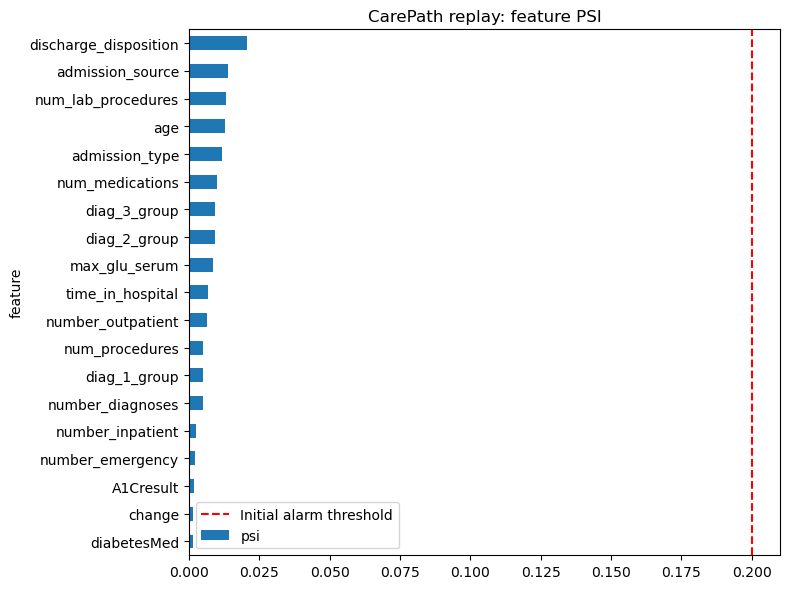

No CloudWatch datapoints visible yet. Rerun this cell after ingestion.


,AlarmName,StateValue,StateReason
0,CarePath-replay-local-artifact-0d4d31c0d1b5-Cl...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
1,CarePath-replay-local-artifact-0d4d31c0d1b5-In...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
2,CarePath-replay-local-artifact-0d4d31c0d1b5-In...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
3,CarePath-replay-local-artifact-0d4d31c0d1b5-Ma...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
4,CarePath-replay-local-artifact-0d4d31c0d1b5-Pr...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
5,CarePath-replay-local-artifact-0d4d31c0d1b5-Re...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
6,CarePath-replay-local-artifact-0d4d31c0d1b5-Re...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation
7,CarePath-replay-local-artifact-0d4d31c0d1b5-Un...,INSUFFICIENT_DATA,Unchecked: Initial alarm creation


In [18]:
if not drift_table.empty:
    ax = drift_table.sort_values("psi").plot.barh(x="feature", y="psi", figsize=(8, 6), legend=False,
                                                title=f"CarePath {MODE}: feature PSI")
    ax.axvline(THRESHOLDS["MaxFeaturePSI"], color="red", linestyle="--", label="Initial alarm threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()
if PUBLISH_TO_AWS:
    end = datetime.now(timezone.utc)
    points = cw.get_metric_statistics(Namespace=NAMESPACE, MetricName="MeanRiskScore", Dimensions=DIMENSIONS,
        StartTime=end-timedelta(hours=3), EndTime=end, Period=PERIOD_SECONDS, Statistics=["Average"])["Datapoints"]
    history = pd.DataFrame(points)
    if len(history):
        history = history.sort_values("Timestamp")
        display(history)
        history.plot(x="Timestamp", y="Average", marker="o", title="MeanRiskScore retrieved from CloudWatch")
        plt.show()
    else:
        print("No CloudWatch datapoints visible yet. Rerun this cell after ingestion.")
    states = cw.describe_alarms(AlarmNames=alarm_names)["MetricAlarms"]
    display(pd.DataFrame([{k: a.get(k) for k in ["AlarmName", "StateValue", "StateReason"]} for a in states]))

## 10. Operate this monitor

In [19]:
RUN_CLEANUP = False
if RUN_CLEANUP and PUBLISH_TO_AWS:
    if alarm_names:
        cw.delete_alarms(AlarmNames=alarm_names)
    cw.delete_dashboards(DashboardNames=[RESOURCE_NAME])
    print("Removed this notebook's alarms and dashboard.")